In [1]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["font.family"] = "Times New Roman"
sample = pd.read_csv('sample1_underpayment_audit.csv')
sample

,claim_id,payer,service_type,billed_amt,allowed_amt,paid_amt,days_to_pay,claim_status,flag_reason
0,C001,Aetna,OfficeVisit,180,120,120.0,18,Paid,NaN
1,C002,Aetna,Lab,95,60,45.0,25,Paid,Underpaid
2,C003,Aetna,Imaging,1200,700,700.0,41,Paid,NaN
3,C004,Aetna,Lab,110,65,65.0,19,Paid,NaN
4,C005,Aetna,OfficeVisit,200,130,100.0,33,Paid,Underpaid
5,C006,Aetna,Imaging,1500,900,0.0,60,Denied,Denial
6,C007,BCBS,OfficeVisit,175,115,115.0,14,Paid,NaN
7,C008,BCBS,Lab,90,55,55.0,16,Paid,NaN
8,C009,BCBS,Imaging,980,620,600.0,28,Paid,Underpaid
9,C010,BCBS,OfficeVisit,210,140,140.0,22,Paid,NaN


In [2]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   claim_id      24 non-null     object 
 1   payer         24 non-null     object 
 2   service_type  24 non-null     object 
 3   billed_amt    24 non-null     int64  
 4   allowed_amt   24 non-null     int64  
 5   paid_amt      23 non-null     float64
 6   days_to_pay   24 non-null     int64  
 7   claim_status  24 non-null     object 
 8   flag_reason   10 non-null     object 
dtypes: float64(1), int64(3), object(5)
memory usage: 1.8+ KB


#### 1. Handling Missing Values

In [4]:
sample.isnull().sum()

claim_id         0
payer            0
service_type     0
billed_amt       0
allowed_amt      0
paid_amt         1
days_to_pay      0
claim_status     0
flag_reason     14
dtype: int64

In [5]:
sample[sample["paid_amt"].isnull()]

,claim_id,payer,service_type,billed_amt,allowed_amt,paid_amt,days_to_pay,claim_status,flag_reason
21,C022,Cigna,OfficeVisit,195,130,NaN,27,Paid,MissingPayment


#### Findings and Recommendations
- Because the payment amount is a key financial field, I shouldn’t impute it with an average or zero (doing so can distort 
underpayment classification and the amount to be recovered).

- Priority check: Go back to the billing system and remittance sources (ERA/EOB) to confirm whether the payment has not been 
posted yet or whether the data pipeline dropped the field.

- To do: Temporarily flag C022 as “Payment Missing – Requires Verification” and exclude it from the underpaid rate calculation, 
but list it separately in the report so it doesn’t get overlooked.

#### 2. Handling Outliers

In [8]:
# Treat days_to_pay values outside the IQR bounds as outliers
# 1.IQR bounds
q1 = sample["days_to_pay"].quantile(0.25)
q3 = sample["days_to_pay"].quantile(0.75)
iqr = q3 - q1
print('iqr:', iqr)

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print('Upper Bound:', upper, "Lower Bound:", lower)

# 2. IQR outlier flag
is_iqr_outlier = (sample["days_to_pay"] < (lower)) | (sample["days_to_pay"] >(upper))
iqr_outlier = sample[is_iqr_outlier]
iqr_outlier

iqr: 17.0
Upper Bound: 61.5 Lower Bound: -6.5


,claim_id,payer,service_type,billed_amt,allowed_amt,paid_amt,days_to_pay,claim_status,flag_reason
22,C023,Cigna,Lab,88,52,52.0,180,Paid,LatePay


In [9]:
# Treat billed_amt values outside the IQR bounds as outliers
# 1. IQR bounds
q1 = sample["billed_amt"].quantile(0.25)
q3 = sample["billed_amt"].quantile(0.75)
iqr = q3 - q1
print('iqr:', iqr)

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr
print('Upper Bound:', upper, "Lower Bound:", lower)

# 2. IQR outlier flag
is_iqr_outlier = (sample["billed_amt"] < (lower)) | (sample["billed_amt"] >(upper))
iqr_outlier = sample[is_iqr_outlier]
iqr_outlier

iqr: 1021.25
Upper Bound: 2656.875 Lower Bound: -1428.125


,claim_id,payer,service_type,billed_amt,allowed_amt,paid_amt,days_to_pay,claim_status,flag_reason
23,C024,Cigna,Imaging,9000,900,900.0,44,Paid,OutlierBilled


#### Findings and Recommendations
- C22: This may be driven by payer processing delays, additional documentation requests, or a bottleneck in the billing workflow.
To do: It’s worth investigating the process constraint.

- C23: This may be due to a unit-of-measure error, or combined billing.
To do: Data accuracy must be confirmed before any follow-up or recovery action

#### 3. Group Comparison

In [12]:
sample["is_underpaid"] = (sample["flag_reason"].str.contains("underpaid", case=False, na=False).astype(int))
df_underpaid_pct = sample.groupby("payer")["is_underpaid"].mean().rename("underpaid_pct").reset_index()
df_underpaid_pct.style.format({"underpaid_pct": "{:.1%}"})

,payer,underpaid_pct
0,Aetna,33.3%
1,BCBS,16.7%
2,Cigna,16.7%
3,United,16.7%


([0, 1, 2, 3],
 [Text(0, 0, 'Aetna'),
  Text(1, 0, 'BCBS'),
  Text(2, 0, 'Cigna'),
  Text(3, 0, 'United')])

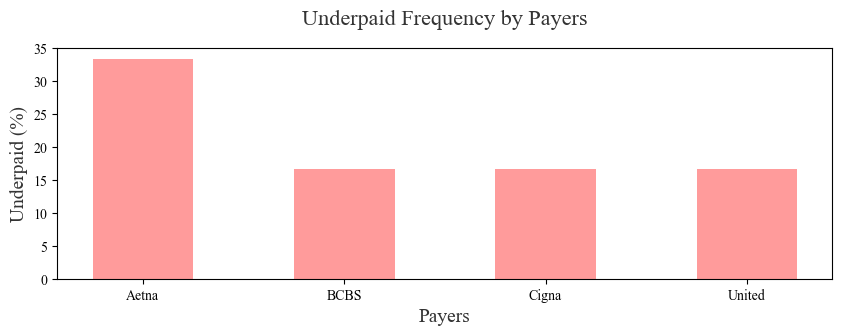

In [13]:
# Visualization
x = df_underpaid_pct["payer"]
y = df_underpaid_pct["underpaid_pct"]*100

plt.figure(figsize=(10,3))
plt.bar(x, y, color="#ff9b9b", width=0.5)
plt.title("Underpaid Frequency by Payers", y=0.98, fontsize=16, fontweight="regular", alpha = 0.8, pad = 20)
plt.xlabel("Payers", fontsize = 14, alpha = 0.8)
plt.ylabel("Underpaid (%)",fontsize = 14, alpha = 0.8)
plt.xticks(rotation=0) 

In [14]:
df_underpaid = sample[sample["is_underpaid"] == 1]
df_underpaid
df_underpaid["underpaid_by"] = df_underpaid["allowed_amt"] - df_underpaid["paid_amt"]
df_underpayment = df_underpaid.groupby("payer")["underpaid_by"].mean().rename("underpayment").reset_index()
df_underpayment

C:\Users\likew\AppData\Local\Temp\ipykernel_26428\4138633582.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_underpaid["underpaid_by"] = df_underpaid["allowed_amt"] - df_underpaid["paid_amt"]


,payer,underpayment
0,Aetna,22.5
1,BCBS,20.0
2,Cigna,15.0
3,United,220.0


([0, 1, 2, 3],
 [Text(0, 0, 'Aetna'),
  Text(1, 0, 'BCBS'),
  Text(2, 0, 'Cigna'),
  Text(3, 0, 'United')])

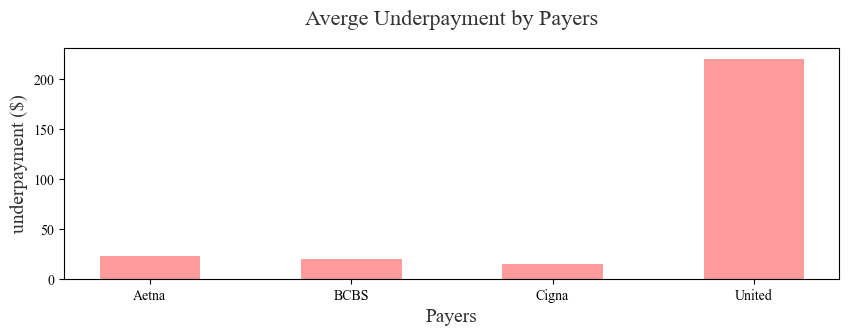

In [15]:
# Visualization
x = df_underpayment["payer"]
y = df_underpayment["underpayment"]

plt.figure(figsize=(10,3))
plt.bar(x, y, color="#ff9b9b", width=0.5)
plt.title("Averge Underpayment by Payers", y=0.98, fontsize=16, fontweight="regular", alpha = 0.8, pad = 20)
plt.xlabel("Payers", fontsize = 14, alpha = 0.8)
plt.ylabel("underpayment ($)",fontsize = 14, alpha = 0.8)
plt.xticks(rotation=0) 

#### Findings and Recommendations
- By frequency, Aetna shows the highest risk, with the highest underpayment rate (33.3%).

- By financial impact, United has the largest average underpayment per case (~$220), so it’s worth prioritizing recovery efforts 
for that service type and/or United’s payment process.

- Cigna’s underpayment percent may look moderate, but the combination of a missing payment amount and an extremely long days-to-pay 
suggests both data quality and process issues. Claim C022 specifically requires payment verification.

#### 4. Summary
- Among the paid claims in this batch, Aetna has the highest underpayment rate (33.3%), suggesting more frequent issues such as incorrect contract allowance application or short payments.

- Although United shows a lower underpayment rate (~16.7%), it has the largest average underpayment per claim ($220), so prioritizing higher-dollar recoveries can improve collection efficiency.

- We also identified data quality and process risks: Cigna has a missing payment amount (C022) and an extremely delayed payment (C023, 180 days), which should be verified and tracked through the payment workflow.

- Next steps should follow two tracks: (1) generate a recovery worklist for Aetna/United underpaid claims with supporting evidence fields and contract references, and (2) establish an exception-handling SOP for missing/late payment cases.

- If we confirm common underpayment patterns with the billing/collections teams (e.g., payer + service type + flag reason), we can feed those rules back into the system to reduce manual review going forward.

#### 5. Assumptions & Limitations:

- This analysis assumes allowed_amt accurately represents the contracted allowed amount; in practice, it should be calculated from or validated against the fee schedule/contract table, otherwise underpayments may be misclassified.

- The underpayment rate is calculated only for claims with claim_status = "Paid" and non-missing paid_amt; Denied, Pending, and missing-payment cases require separate workflows and should not be treated as underpayments.

- The dataset is small and lacks key fields, which limits root-cause investigation and the ability to confidently explain why underpayments occurred.